In [242]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(torch.version.cuda)

True
NVIDIA GeForce RTX 3070 Ti Laptop GPU
13.0


In [243]:

# Matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
# Numpy
import numpy as np
# Pandas
import pandas as pd
# Torch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchmetrics.classification import BinaryF1Score, BinaryPrecision, BinaryRecall, BinaryAveragePrecision
# Preprocessing
from sklearn.preprocessing import RobustScaler
# Imbalance handling
import importlib
# Helper functions (additional file)
from helper_functions import *

In [244]:
# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Make CUDA ops deterministic (can be slightly slower)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Use GPU if available, else use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print(f"Using seed: {SEED}")

cuda
Using seed: 42


In [245]:
# Columns for dataset
filepath = 'train_creditcard.csv'
df = pd.read_csv(filepath)
print(df.columns)

# Load the dataset
V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11, V12, V13, V14, V15, V16, V17, V18, V19, V20, V21, V22, V23, V24, V25, V26, V27, V28, amount, inputs, outputs = load_creditcard_dataset(filepath)

print("Input shape:", inputs.shape)
print("Output shape:", outputs.shape)
print("Number of samples with class 0:", len(outputs) - sum(outputs))
print("Number of samples with class 1:", sum(outputs))

print()


Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')
Input shape: (227845, 28)
Output shape: (227845,)
Number of samples with class 0: 227451
Number of samples with class 1: 394



In [246]:
class CreditCardDataset(Dataset):
    def __init__(self,csv_path, amount_scaler=None):
        feature_cols = [f'V{i}' for i in range(1, 29)] + ['Amount'] 
        df_local = pd.read_csv(csv_path, usecols=feature_cols + ['Class'])
        
        if amount_scaler is not None:
            # Use scaler fitted on training data only.
            df_local.loc[:, 'Amount'] = amount_scaler.transform(df_local[['Amount']]).astype(np.float32).ravel()
        
        # Pre-materialize arrays once to avoid expensive row-wise pandas indexing in __getitem__ 
        self.features = df_local[feature_cols].to_numpy(dtype=np.float32)
        self.labels = df_local['Class'].to_numpy(dtype=np.float32)

    def __len__(self):
        return len(self.labels) 
    
    def __getitem__(self, idx):
        x = torch.from_numpy(self.features[idx])
        y = torch.tensor(self.labels[idx], dtype=torch.float32) 
        return x, y


In [247]:
feature_columns = [f'V{i}' for i in range(1, 29)] + ['Amount']
X_train = df[feature_columns].values.astype(np.float32)
y_train = df['Class'].values.astype(np.int64)

try:
    SMOTETomek = importlib.import_module('imblearn.combine').SMOTETomek
except ModuleNotFoundError as e:
    raise ModuleNotFoundError(
        "imblearn is required for SMOTE-Tomek. Install it with: pip install imbalanced-learn"
    ) from e

# Gentle augmentation: train set only, target fraud rate ~1%.
target_fraud_rate = 0.01
sampling_ratio = target_fraud_rate / (1.0 - target_fraud_rate)  # minority / majority

smote_tomek = SMOTETomek(sampling_strategy=sampling_ratio, random_state=SEED)
X_resampled, y_resampled = smote_tomek.fit_resample(X_train, y_train)

# If Tomek cleanup shifts ratio, trim excess fraud to keep it near 1%.
legit_idx = np.where(y_resampled == 0)[0]
fraud_idx = np.where(y_resampled == 1)[0]
target_fraud_count = int(round((target_fraud_rate / (1.0 - target_fraud_rate)) * len(legit_idx)))
if len(fraud_idx) > target_fraud_count:
    rng = np.random.default_rng(SEED)
    keep_fraud = rng.choice(fraud_idx, size=target_fraud_count, replace=False)
    keep_idx = np.concatenate([legit_idx, keep_fraud])
    rng.shuffle(keep_idx)
    X_resampled = X_resampled[keep_idx]
    y_resampled = y_resampled[keep_idx]

augmented_train_df = pd.DataFrame(X_resampled, columns=feature_columns)
augmented_train_df['Class'] = y_resampled.astype(np.float32)
augmented_filepath = 'train_creditcard_smotetomek_1pct.csv'
augmented_train_df.to_csv(augmented_filepath, index=False)

# Fit RobustScaler on training data only (augmented train set).
amount_scaler = RobustScaler()
amount_scaler.fit(augmented_train_df[['Amount']])

# Set dynamic pos_weight from augmented class balance.
num_pos = float((y_resampled == 1).sum())
num_neg = float((y_resampled == 0).sum())
pos_weight_value = num_neg / max(num_pos, 1.0)

# Keep existing dataset class and training code unchanged.
filepath = augmented_filepath

print(f"Original train fraud rate: {100.0 * y_train.mean():.4f}%")
print(f"Augmented train fraud rate: {100.0 * augmented_train_df['Class'].mean():.4f}%")
print(f"Augmented train size: {len(augmented_train_df):,}")
print(f"Using pos_weight from augmented data: {pos_weight_value:.2f}")

cc_dataset = CreditCardDataset(csv_path=filepath, amount_scaler=amount_scaler)
batch_size = 64
train_gen = torch.Generator()
train_gen.manual_seed(SEED)
cc_dataloader = DataLoader(cc_dataset, batch_size=batch_size, shuffle=True, generator=train_gen)

Original train fraud rate: 0.1729%
Augmented train fraud rate: 0.9947%
Augmented train size: 229,724
Using pos_weight from augmented data: 99.54


In [248]:
#Creation of a gated layer
class GatedLayer(nn.Module):
    def __init__(self, input_size, output_size):
        super(GatedLayer, self).__init__()
        self.linear = nn.Linear(input_size, output_size)  # Linear transformation
        self.gate = nn.Linear(input_size, output_size)    # Gate transformation
        self.sigmoid = nn.Sigmoid()                       # Sigmoid activation for gate

    def forward(self, x):
        linear_output = self.linear(x)                    # Compute linear output
        gate_output = self.sigmoid(self.gate(x))         # Compute gate output and apply sigmoid
        return linear_output * gate_output                # Element-wise multiplication of linear output and gate output

In [249]:
#Architecture of the model
class CreditCardFraudModel(nn.Module):
    def __init__(self):
        super().__init__()
        # Output layer with input size 8 and output size 1
        self.gated_layer = GatedLayer(29, 64)                 # Input layer with input size 29 (number of features) and output size 
        self.hidden_layer1 = nn.Linear(64, 32)
        self.hidden_layer2 = nn.Linear(32,16)                # First hidden layer with input size 32 and output size 16
        self.output_layer = nn.Linear(16, 1)     # Output layer with input size 16 and output size 1

        # Activation functions
        self.relu = nn.ReLU()
        
        self.dropout = nn.Dropout(p=0.3)  # Dropout layer with dropout probability of 0.3
        
        # Loss function and accuracy metric
        self.loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32))
        self.accuracy_fn = BinaryF1Score()  
        self.batchnorm1 = nn.BatchNorm1d(64)  # Batch normalization for gated layer output (64 features)
        

    def forward(self, x):
        x = self.gated_layer(x)                  # Pass through gated layer
        x = self.batchnorm1(x)                 # Apply batch normalization
        x = self.relu(x)                       # Apply ReLU activation
        x = self.hidden_layer1(x)               # Pass through first hidden layer
        x = self.relu(x)                       # Apply ReLU activation
        x = self.hidden_layer2(x)              # Pass through second hidden layer
        x = self.relu(x)                       # Apply ReLU activation
        x = self.dropout(x)                    # Apply dropout
        x = self.output_layer(x)                # Pass through output layer
        return x                                # Return raw logits (no sigmoid)

In [250]:
model = CreditCardFraudModel()

total_params = sum(p.numel() for p in model.parameters())
print(f"Total trainable parameters: {total_params}")

Total trainable parameters: 6593


In [251]:

model = CreditCardFraudModel().to(device)

# Training hyperparameters
num_epochs = 100
# TODO: Set a reasonable learning rate
learning_rate = 0.0001

# Create optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)  # Added L2 regularization with weight decay
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=num_epochs, eta_min=1e-6
)

# Validation data loader
valid_file_path = 'valid_creditcard.csv'
valid_dataset = CreditCardDataset(csv_path=valid_file_path, amount_scaler=amount_scaler)
valid_dataloader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

# Training history for plotting
loss_history = []
accuracy_history = []
val_loss_history = []
val_f1_history = []
val_prauc_history = []

# Training loop
for epoch in range(num_epochs):
    model.train()
    train_f1 = BinaryF1Score().to(device)
    train_precision = BinaryPrecision().to(device)
    train_recall = BinaryRecall().to(device)
    train_prauc = BinaryAveragePrecision().to(device)
    epoch_loss = 0.0
    num_batches = 0
    
    for batch in cc_dataloader:
        # Unpack batch
        inputs_batch, labels_batch = batch
        inputs_batch = inputs_batch.to(device)
        labels_batch = labels_batch.to(device).reshape(-1, 1)
        
        # TODO: Zero the gradients
        optimizer.zero_grad()
        # TODO: Forward pass - get predictions
        predictions = model(inputs_batch)
        # TODO: Compute loss
        loss = model.loss_fn(predictions, labels_batch.to(torch.float32))
        # TODO: Backward pass
        loss.backward()
        # TODO: Update weights
        optimizer.step()
        # Track metrics
        epoch_loss += loss.item()
        targets_int = labels_batch.int()
        train_f1.update(predictions, targets_int)
        train_precision.update(predictions, targets_int)
        train_recall.update(predictions, targets_int)
        train_prauc.update(predictions, targets_int)
        num_batches += 1
    
    # Compute training metrics at end of epoch
    avg_loss = epoch_loss / num_batches
    epoch_f1 = train_f1.compute().item()
    epoch_precision = train_precision.compute().item()
    epoch_recall = train_recall.compute().item()
    epoch_prauc = train_prauc.compute().item()
    loss_history.append(avg_loss)
    accuracy_history.append(epoch_f1)

    # Validation loop
    model.eval()
    val_loss = 0.0
    val_batches = 0
    val_f1 = BinaryF1Score().to(device)
    val_precision = BinaryPrecision().to(device)
    val_recall = BinaryRecall().to(device)
    val_prauc = BinaryAveragePrecision().to(device)

    with torch.no_grad():
        for val_inputs, val_labels in valid_dataloader:
            val_inputs = val_inputs.to(device)
            val_labels = val_labels.to(device).reshape(-1, 1)
            val_predictions = model(val_inputs)

            v_loss = model.loss_fn(val_predictions, val_labels.to(torch.float32))
            val_loss += v_loss.item()

            val_targets_int = val_labels.int()
            val_f1.update(val_predictions, val_targets_int)
            val_precision.update(val_predictions, val_targets_int)
            val_recall.update(val_predictions, val_targets_int)
            val_prauc.update(val_predictions, val_targets_int)
            val_batches += 1

    avg_val_loss = val_loss / val_batches
    epoch_val_f1 = val_f1.compute().item()
    epoch_val_precision = val_precision.compute().item()
    epoch_val_recall = val_recall.compute().item()
    epoch_val_prauc = val_prauc.compute().item()
    val_loss_history.append(avg_val_loss)
    val_f1_history.append(epoch_val_f1)
    val_prauc_history.append(epoch_val_prauc)

    current_lr = optimizer.param_groups[0]['lr']

    # Print progress every epoch
    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {avg_loss:.4f}, Train F1: {epoch_f1:.4f}, Train Precision: {epoch_precision:.4f}, "
        f"Train Recall: {epoch_recall:.4f}, Train PR-AUC: {epoch_prauc:.4f} | "
        f"Val Loss: {avg_val_loss:.4f}, Val F1: {epoch_val_f1:.4f}, Val Precision: {epoch_val_precision:.4f}, "
        f"Val Recall: {epoch_val_recall:.4f}, Val PR-AUC: {epoch_val_prauc:.4f}, LR: {current_lr:.8f}"
    )

    scheduler.step()

print("Training complete!")

Epoch [1/100] Train Loss: 0.4683, Train F1: 0.1204, Train Precision: 0.0644, Train Recall: 0.9287, Train PR-AUC: 0.8237 | Val Loss: 0.1183, Val F1: 0.2383, Val Precision: 0.1365, Val Recall: 0.9388, Val PR-AUC: 0.7090, LR: 0.00010000
Epoch [2/100] Train Loss: 0.2054, Train F1: 0.3230, Train Precision: 0.1942, Train Recall: 0.9589, Train PR-AUC: 0.9043 | Val Loss: 0.1006, Val F1: 0.2486, Val Precision: 0.1438, Val Recall: 0.9184, Val PR-AUC: 0.7280, LR: 0.00009998
Epoch [3/100] Train Loss: 0.1704, Train F1: 0.5045, Train Precision: 0.3414, Train Recall: 0.9659, Train PR-AUC: 0.9218 | Val Loss: 0.0938, Val F1: 0.2786, Val Precision: 0.1642, Val Recall: 0.9184, Val PR-AUC: 0.7339, LR: 0.00009990
Epoch [4/100] Train Loss: 0.1553, Train F1: 0.5178, Train Precision: 0.3534, Train Recall: 0.9685, Train PR-AUC: 0.9293 | Val Loss: 0.0998, Val F1: 0.2118, Val Precision: 0.1197, Val Recall: 0.9184, Val PR-AUC: 0.7247, LR: 0.00009978
Epoch [5/100] Train Loss: 0.1285, Train F1: 0.5460, Train Precis

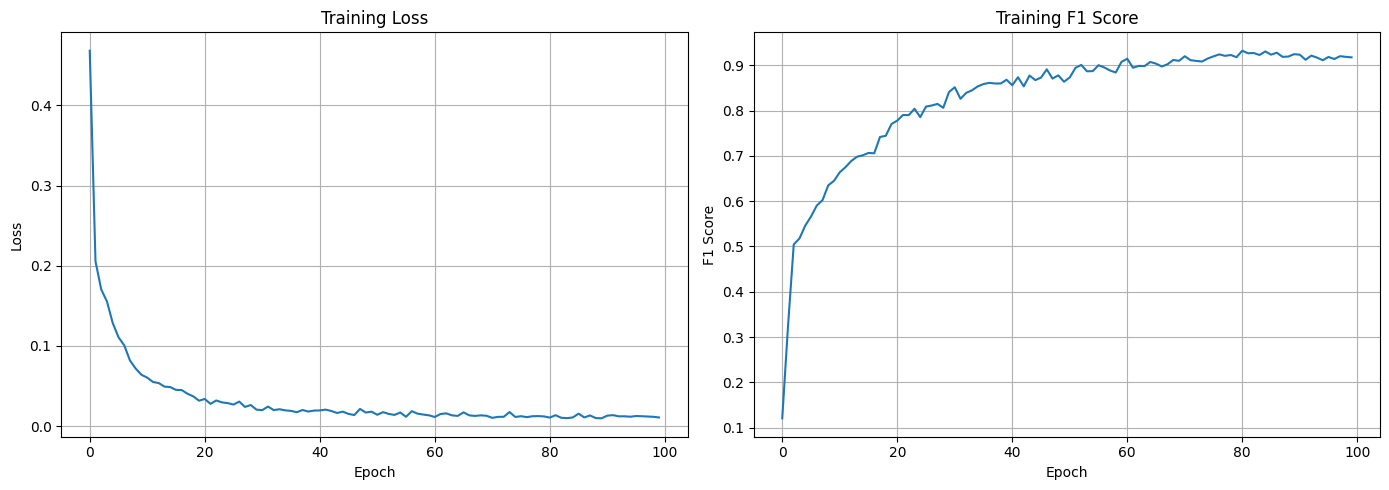

In [252]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(loss_history)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.grid(True)

ax2.plot(accuracy_history)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1 Score')
ax2.set_title('Training F1 Score')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [253]:
test_file_path = 'test_creditcard.csv'
# Load test data with correct feature columns (including 'Amount')
test_df = pd.read_csv(test_file_path)
# Apply scaler fitted on training data only
test_df.loc[:, 'Amount'] = amount_scaler.transform(test_df[['Amount']]).astype(np.float32).ravel()
# Select the same 29 features as in training
feature_columns = [f'V{i}' for i in range(1, 29)] + ['Amount']
test_inputs = test_df[feature_columns].values.astype(np.float32)
test_labels = test_df['Class'].values.astype(np.float32)

# For compatibility with the rest of the notebook
inputs_test = test_inputs
outputs_test = test_labels


# Test the model on unseen data

In [254]:
from sklearn.metrics import confusion_matrix, precision_recall_curve

test_inputs = torch.as_tensor(test_inputs, dtype=torch.float32, device=device)
test_labels = torch.as_tensor(test_labels, dtype=torch.float32, device=device).reshape(-1, 1)

print(f"Number of samples with class 1 in test set: {int((test_labels == 1).sum())}")
print(f"Number of samples with class 0 in test set: {int((test_labels == 0).sum())}")

# Tune threshold on validation set using precision-recall curve
val_probs_list = []
val_true_list = []
model.eval()
with torch.no_grad():
    for val_inputs_batch, val_labels_batch in valid_dataloader:
        val_inputs_batch = val_inputs_batch.to(device)
        val_logits_batch = model(val_inputs_batch)
        val_probs_batch = torch.sigmoid(val_logits_batch).cpu().numpy().ravel()
        val_true_batch = val_labels_batch.cpu().numpy().astype(np.int32).ravel()
        val_probs_list.append(val_probs_batch)
        val_true_list.append(val_true_batch)

val_probs = np.concatenate(val_probs_list)
val_true = np.concatenate(val_true_list)
precision_curve, recall_curve, thresholds = precision_recall_curve(val_true, val_probs)

if len(thresholds) == 0:
    threshold = 0.5
    print("Validation PR curve did not return thresholds; using threshold=0.5")
else:
    f1_curve = (2 * precision_curve[:-1] * recall_curve[:-1]) / (precision_curve[:-1] + recall_curve[:-1] + 1e-12)
    best_idx = int(np.nanargmax(f1_curve))
    threshold = float(thresholds[best_idx])
    print(f"Tuned threshold from validation PR curve: {threshold:.4f}")
    print(f"Validation F1 at tuned threshold: {f1_curve[best_idx]:.4f}")

# Predict test logits and probabilities
with torch.no_grad():
    predictions = model(test_inputs)

y_true = test_labels.int()
probs = torch.sigmoid(predictions)

test_f1 = BinaryF1Score(threshold=threshold).to(device)(probs, y_true).item()
test_precision = BinaryPrecision(threshold=threshold).to(device)(probs, y_true).item()
test_recall = BinaryRecall(threshold=threshold).to(device)(probs, y_true).item()
test_auprc = BinaryAveragePrecision().to(device)(probs, y_true).item()

y_true_cpu = y_true.cpu().numpy().ravel()
y_pred_cpu = (probs >= threshold).int().cpu().numpy().ravel()
cm = confusion_matrix(y_true_cpu, y_pred_cpu)

print(f"  TN={cm[0,0]:>6,}  FP={cm[0,1]:>5,}")
print(f"  FN={cm[1,0]:>6,}  TP={cm[1,1]:>5,}")

print(f"  AUPRC    : {test_auprc:.4f}   <- key metric for imbalanced data")
print(f"  F1 Score : {test_f1:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall   : {test_recall:.4f}")

test_loss = model.loss_fn(predictions, test_labels).item()
print(f"Test Loss: {test_loss:.4f}")


Number of samples with class 1 in test set: 49
Number of samples with class 0 in test set: 28432
Tuned threshold from validation PR curve: 0.9998
Validation F1 at tuned threshold: 0.8542
  TN=28,426  FP=    6
  FN=    15  TP=   34
  AUPRC    : 0.8107   <- key metric for imbalanced data
  F1 Score : 0.7640
  Precision: 0.8500
  Recall   : 0.6939
Test Loss: 0.2995
